In [1]:
# %pip install joblib


# EXP1 是英文期刊
# EXP2 是碩論

# Setting TV

In [1]:
import pandas as pd
from datetime import datetime
import os
from pathlib import Path

# 如果尚未設定過工作目錄，才切換到 project_root
if not globals().get('_project_dir_set', False):
    notebook_dir = Path(os.getcwd())
    project_root = notebook_dir.parent  # 上一層
    os.chdir(project_root)
    print("工作目錄設為：", os.getcwd())
    globals()['_project_dir_set'] = True
else:
    print("工作目錄已設定為：", os.getcwd())

# fee
fee = {
    "tax_stock": 0.003,  # 賣出0.003
    "tax_future": 0.00002 * 2,  # 買進與賣出各0.00002
    "fee_stock": 0.001425 * 2,  # 券商手續費公道價，買進與賣出各0.001425
    "fee_future": 0.00002 * 2,  # 各家不大相同，以交易稅計算
    "sliding_price": 0.00001,  # 滑價
}
# tw_index_fee = 0
tw_stock_fee = 0
# tw_stock_fee = fee["tax_stock"] + fee["fee_stock"] + fee["sliding_price"]
tw_index_fee = fee["tax_future"] + fee["fee_future"] + fee["sliding_price"]

# stock list
data = [
    ["2330", "台積電", "tw"],
    ["2454", "聯發科", "tw"],
    ["2317", "鴻海", "tw" ],
    ["2881", "富邦金", "tw" ],
    ["2308", "台達電", "tw" ],
    ["2882", "國泰金", "tw" ],
    ["2412", "中華電", "tw" ],
    ["2382", "廣達", "tw" ],
    ["2891", "中信金", "tw" ],
    ["3711", "日月光投控", "tw"], #10
    # # ["2886", "兆豐金", "tw" ],
    # # ["2303", "聯電", "tw" ],
    # ["2357", "華碩", "tw" ],   
    # # ["2885", "元大金", "tw" ],  # 15
    # ["2603", "長榮", "tw" ],     
    # ["2884", "玉山金", "tw" ],
    # # ["1216", "統一", "tw" ],
    # ["3045", "台灣大", "tw" ],
    # ["2892", "第一金", "tw" ],
    # # ["2880", "華南金", "tw" ],   #20
    
    # ["2002", "中鋼", "tw" ],
    # ["2345", "智邦", "tw" ],
    # ["5880", "合庫金", "tw" ],
    # ["6505", "台塑化", "tw" ],
    # ["6669", "緯穎", "tw" ],
    # ["3008", "大立光", "tw" ],
    # ["2395", "研華", "tw" ],
    # ["2207", "和泰車", "tw" ],
    # ["3034", "聯詠", "tw" ],
    # ["3231", "緯創", "tw" ]      #30
    
    # ["2330", "台積電", "tw"],
    # ["2454", "聯發科", "tw" ],
    # ["2317", "鴻海", "tw" ],
    # ["2881", "富邦金", "tw" ],
    # ["2308", "台達電", "tw" ],
    # ["2882", "國泰金", "tw" ],
    # ["2412", "中華電", "tw" ],
    # ["2382", "廣達", "tw" ],
    # ["2891", "中信金", "tw" ],
    # ["6505", "台塑化", "tw" ],
    # ["3231", "緯創", "tw"],
    # ["2207", "和泰車", "tw"],
    # ["3661", "世芯", "tw"],
    # ["2603", "長榮", "tw"],
    # ["2408", "南亞科", "tw"],
    
    # ["6214", "精誠", "tw"],
    # ["3045", "台灣大", "tw"],
    # ["2379", "瑞昱", "tw"],
    # ["2357", "華碩", "tw"],
    # ["2345", "智邦", "tw"],
    
    # # old us
    # ["AAPL", "Apple Inc.", "us"],
    # ["MSFT", "Microsoft", "us"],    # 20
    # ["NVDA", "Nvidia", "us"],
    # ["AMZN", "Amazon inc.", "us"],
    # ["JPM", "JPMorgan Chase", "us"],
    # ["BA", "Boeing", "us"],
    # ["UNH", "UnitedHealth Group", "us"],
    # ["CSCO", "Cisco", "us"],
    # ["CVX", "Chevron", "us"],
    # ["PG", "Procter & Gamble", "us"],
    # ["DIS", "Disney", "us"],
    
    # ["META", "Meta Platforms", "us"],
    # ["GOOGL", "Google", "us"],
    # ["TSLA", "Tesla", "us"],
    # ["AVGO", "Broadcom", "us"],
    # ["BRK", "Berkshire Hathaway", "us"],
    # ["MRNA", "Moderna", "us"],
    # ["PYPL", "PayPal", "us"],
    # ["BAC", "Bank of America", "us"],
    # ["HD", "Home Depot", "us"],
    # ["WMT", "Walmart", "us"],
    # ["INTC", "Intel", "us"],
    # ["ADBE", "Adobe", "us"],
    
    # # DJIA 
    # ["AAPL", "Apple Inc.", "us"],
    # ["AMGN", "Amgen", "us"],
    # ["AMZN", "Amazon inc.", "us"],
    # ["AXP", "American Express", "us"],
    # ["BA", "Boeing", "us"],
    # ["CSCO", "Cisco", "us"],
    # ["CVX", "Chevron", "us"],
    # ["KO", "Coca-Cola", "us"],
    # ["CAT", "Caterpillar Inc.", "us"],
    # ["CRM", "Salesforce", "us"],    # 10
    # ["DIS", "Disney", "us"],
    # ["GS", "Goldman Sachs", "us"],
    # ["HD", "Home Depot", "us"],
    # ["HON", "Honeywell", "us"],
    # ["IBM", "IBM", "us"],
    # ["JNJ", "Johnson & Johnson", "us"],
    # ["JPM", "JPMorgan Chase", "us"],
    # ["MCD", "McDonald's", "us"],
    # ["MRK", "Merck", "us"],
    # ["MSFT", "Microsoft", "us"],    # 20
    # ["MMM", "3M", "us"],
    # ["NKE", "Nike", "us"],
    # ["NVDA", "Nvidia", "us"],
    # ["PG", "Procter & Gamble", "us"],
    # ["SHW", "Sherwin-Williams", "us"],
    # ["TRV", "Travelers", "us"],
    # ["UNH", "UnitedHealth Group", "us"],
    # ["VZ", "Verizon", "us"],
    # ["V", "Visa", "us"],
    # ["WMT", "Walmart", "us"],   # 30
    
    # Removed from DJIA in past 3 years
    # ["INTC", "Intel", "us"],
    # ["DOW", "Dow Inc.", "us"],
    # ["WBA", "Walgreens Boots Alliance", "us"],
    
    # Not in DJIA
    # ["ADBE", "Adobe", "us"],
    # ["AVGO", "Broadcom", "us"],
    # ["BRK", "Berkshire Hathaway", "us"],
    # ["GOOGL", "Google", "us"],
    # ["META", "Meta Platforms", "us"],
    # ["MRNA", "Moderna", "us"],
    # ["NVDA", "Nvidia", "us"],
    # ["PYPL", "PayPal", "us"],
    # ["TSLA", "Tesla", "us"],
    # ["BAC", "Bank of America", "us"],
]

# 指數
comp_twii = [
    ["2308", "台達電", "tw"],
    ["2317", "鴻海", "tw"],
    ["2330", "台積電", "tw"],
    ["2382", "廣達", "tw"],
    ["2412", "中華電", "tw"],
    ["2454", "聯發科", "tw"],
    ["2881", "富邦金", "tw"],
    ["2882", "國泰金", "tw"],
    ["2891", "中信金", "tw"],
    ["6505", "台塑化", "tw"],
]

comp_spx = [
    ["AAPL", "Apple Inc.", "us"],
    ["MSFT", "Microsoft", "us"],
    ["NVDA", "Nvidia", "us"],
    ["AMZN", "Amazon inc.", "us"],
    ["META", "Meta Platforms", "us"],
    ["GOOGL", "Google", "us"],
    ["TSLA", "Tesla", "us"],
    ["AVGO", "Broadcom", "us"],
    ["BRK", "Berkshire Hathaway", "us"],
    ["JPM", "JPMorgan Chase", "us"],
]

comp_djia = [
    ["GS", "Goldman Sachs", "us"],
    ["UNH", "UnitedHealth Group", "us"],
    ["MSFT", "Microsoft", "us"],
    ["HD", "Home Depot", "us"],
    ["CAT", "Caterpillar", "us"],
    ["V", "Visa", "us"],
    ["CRM", "Salesforce", "us"],
    ["AXP", "American Express", "us"],
    ["MCD", "McDonald's", "us"],
]


market_index = [
    ["twii", "台灣加權指數", "tw", comp_twii],
    # ["spx", "S&P 500", "us", comp_spx],
    # ["djia", "道瓊指數", "us", comp_djia],
    
    # ["tx", "台灣指數期貨", "tw", comp_twii],
]

data_range_tv = [
    # ["20220101", "20220110", 15.5], # test
    ["20220101", "20241231", 1], # tv1
    ["20220101", "20241231", 2], # tv2
    ["20220101", "20241231", 3], # tv3
    ["20220101", "20241231", 4], # tv4
    ["20220101", "20241231", 5], # tv5
    ["20220101", "20241231", 6], # tv6
    ["20220101", "20241231", 7], # tv7
    ["20220101", "20241231", 8], # tv8
    ["20220101", "20241231", 9], # tv9
    ["20220101", "20241231", 10], # tv10
    ["20220101", "20241231", 11], # tv11
    ["20220101", "20241231", 12], # tv12
    ["20220101", "20241231", 13], # tv13
    ["20220101", "20241231", 14], # tv14
    ["20220101", "20241231", 15], # tv15
    ["20220101", "20241231", 16], # tv16
    ["20220101", "20241231", 17], # tv17
    ["20220101", "20241231", 18], # tv18
    ["20220101", "20241231", 19], # tv19
    ["20220101", "20241231", 20], # tv20    
    ["20220101", "20241231", 21], # tv21
    ["20220101", "20241231", 22], # tv22
    ["20220101", "20241231", 23], # tv23
    ["20220101", "20241231", 24], # tv24
    ["20220101", "20241231", 25], # tv25
    ["20220101", "20241231", 26], # tv26
    ["20220101", "20241231", 27], # tv27
    ["20220101", "20241231", 28], # tv28
    ["20220101", "20241231", 29], # tv29
    ["20220101", "20241231", 30], # tv30
]

工作目錄設為： /Users/yanyifu/Documents/_Coding/LLM Predict Stock


In [2]:
def get_balance_list(list_rtn, start_price):
    balance = start_price
    list_balance = [start_price]
    for rtn in list_rtn[1:]:
        balance = balance * (1 + float(rtn))
        list_balance.append(balance)
    return list_balance

In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from math import ceil, sqrt

def display_all_plots(all_plots):
    # 計算需要的子圖行數與列數（接近正方形排列）
    num_plots = len(all_plots)
    cols = ceil(sqrt(num_plots))  # 列數
    rows = ceil(num_plots / cols)  # 行數

    # 創建一個大的畫布
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    # fig.suptitle("Trading Results for All Stocks", fontsize=16, y=0.95)

    # 確保 axes 是一個 2D 陣列
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1 or cols == 1:
        axes = [axes] if rows == 1 else [[ax] for ax in axes]
    else:
        axes = axes.reshape(rows, cols)

    # 在每個子圖中顯示單獨的圖表
    for idx, single_fig in enumerate(all_plots):
        row, col = divmod(idx, cols)
        ax = axes[row][col]
        
        # 從單個圖表中提取並繪製數據
        for line in single_fig.axes[0].get_lines():
            ax.plot(line.get_xdata(), line.get_ydata(), label=line.get_label())
        
        # 設定標題、標籤與圖例
        ax.set_title(single_fig.axes[0].get_title())
        ax.set_xlabel(single_fig.axes[0].get_xlabel())
        ax.set_ylabel(single_fig.axes[0].get_ylabel())
        ax.legend()
        
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # 設置最多顯示 5 個標籤


    # 移除多餘的空白子圖
    for idx in range(num_plots, rows * cols):
        row, col = divmod(idx, cols)
        fig.delaxes(axes[row][col])

    # 調整整體佈局
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)  # 調整總標題的位置
    plt.show()

In [4]:
def cacl_avg(df_stocks_results, wincount=None, ttl_count=None):
    '''
        only return average row
    '''
    
    average_row = pd.DataFrame()
    average_row['tp'] = [df_stocks_results['tp'].sum()]
    average_row['fp'] = [df_stocks_results['fp'].sum()]
    average_row['tn'] = [df_stocks_results['tn'].sum()]
    average_row['fn'] = [df_stocks_results['fn'].sum()]
    average_row['accuracy'] = (average_row['tp'] + average_row['tn']) / (average_row['tp'] + average_row['tn'] + average_row['fp'] + average_row['fn'])
    average_row['precision'] = average_row['tp'] / (average_row['tp'] + average_row['fp'])
    # EV 算法 每個ev成上avail_count 總和後再除上 avail_count 的平均
    average_row['avail_count'] = [df_stocks_results['avail_count'].sum()]
    average_row['pci_avl_count'] = [df_stocks_results['tp'].sum() + df_stocks_results['fp'].sum()]
    average_row['ev'] = (df_stocks_results['ev'].astype(float) * df_stocks_results['avail_count']).sum() / df_stocks_results['avail_count'].sum()
    average_row['precision_ev'] = (df_stocks_results['precision_ev'].astype(float) * (df_stocks_results['tp'] + df_stocks_results['fp'])).sum() / (df_stocks_results['tp'].sum() + df_stocks_results['fp'].sum())
    if ttl_count is None:
        average_row['win B&H'] = None
    else:
        average_row['win B&H'] = round(wincount / ttl_count, 2)
        
    if 'B&H' in df_stocks_results.columns:
        average_row['B&H'] = df_stocks_results['B&H'].mean()
    if 'RTN' in df_stocks_results.columns:
        average_row['RTN'] = df_stocks_results['RTN'].mean()
    
    return average_row

# TV-1 Factor

In [6]:
from backtest_llm_factor.TV_usable_dt_stock import TV_UsableDT
import pandas as pd
from joblib import Parallel, delayed
from datetime import datetime

avgs = pd.DataFrame()
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def process_stock(stock, i):
    stock_avg_list = [] 
    
    for date_range in data_range_tv:
        env = {
            "stock_id": stock[0],
            "stock_name": stock[1],
            "country": stock[2],
            "start_date": date_range[0],
            "end_date": date_range[1],
            "tv": date_range[2],
            "run_count": str(i)
        }
        print(env['stock_id'], env['stock_name'], env['country'], f"tv{date_range[2]}")
        
        eval_module = TV_UsableDT(env, factors_count=8, expand=1)
        eval_module.run()
        train_datarange, test_datarange = eval_module.split_exp(date_range[2])
        
        mode = 1
        eval_module.training(mode, train_datarange, test_datarange)
        
        result = eval_module.get_result(1)  # Test 結果
        result_test = result["test"]  # Test 結果
        
        # Training & Test 報酬計算
        train_date, train_bnh_balance, train_stag_rtn = eval_module.get_return_list('train')
        train_stag_balance = get_balance_list(train_stag_rtn, train_bnh_balance[0])
        
        list_date, list_bnh_balance, list_stag_rtn = eval_module.get_return_list('test')
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_balance[0])
        
        # 計算天數
        train_N_days = (datetime.strptime(sorted(train_datarange.keys())[-1], '%Y%m%d') - 
                        datetime.strptime(sorted(train_datarange.keys())[0], '%Y%m%d')).days
        test_N_days = (datetime.strptime(sorted(test_datarange.keys())[-1], '%Y%m%d') - 
                       datetime.strptime(sorted(test_datarange.keys())[0], '%Y%m%d')).days

        stock_avg = cacl_avg(pd.DataFrame([result_test]).loc[:, selected_columns])
        stock_avg['stock_id'] = stock[0]
        stock_avg['tv'] = date_range[2]
        stock_avg['Train_RTN'] = (train_stag_balance[-1] / train_bnh_balance[0] - 1) * 100
        stock_avg['Train_B&H'] = (train_bnh_balance[-1] / train_bnh_balance[0] - 1) * 100
        stock_avg['Ann_Train_RTN'] = ((1 + stock_avg['Train_RTN'] / 100) ** (252 / train_N_days) - 1) * 100
        stock_avg['Ann_Train_B&H'] = ((1 + stock_avg['Train_B&H'] / 100) ** (252 / train_N_days) - 1) * 100
        stock_avg['RTN'] = (list_stag_balance[-1] / list_bnh_balance[0] - 1) * 100
        stock_avg['B&H'] = (list_bnh_balance[-1] / list_bnh_balance[0] - 1) * 100
        stock_avg['Ann_RTN'] = ((1 + stock_avg['RTN'] / 100) ** (252 / test_N_days) - 1) * 100
        stock_avg['Ann_B&H'] = ((1 + stock_avg['B&H'] / 100) ** (252 / test_N_days) - 1) * 100
        stock_avg['win B&H'] = "yes" if list_stag_balance[-1] > list_bnh_balance[-1] else "no"

        stock_avg_list.append(stock_avg)
    
    return pd.concat(stock_avg_list) if stock_avg_list else None

def runAll_parallel(i):
    results = Parallel(n_jobs=-1)(delayed(process_stock)(stock, i) for stock in data)
    return pd.concat([res for res in results if res is not None])

# 迭代執行
for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll_parallel(i+1)])
    
tv_avg_df = avgs.groupby("tv")[["RTN", "B&H", "Ann_RTN", "Ann_B&H", "Train_RTN", "Train_B&H", "Ann_Train_RTN", "Ann_Train_B&H"]].mean().reset_index()
tv_avg_df["Test_RTN"] = tv_avg_df["RTN"]
tv_avg_df["Test_B&H"] = tv_avg_df["B&H"]
tv_avg_df["Ann_Test_RTN"] = tv_avg_df["Ann_RTN"]
tv_avg_df["Ann_Test_B&H"] = tv_avg_df["Ann_B&H"]
tv_avg_df["Win B&H"] = tv_avg_df["Ann_Test_RTN"] > tv_avg_df["Ann_Test_B&H"]
tv_avg_df["Diff"] = tv_avg_df["Ann_Test_RTN"] - tv_avg_df["Ann_Test_B&H"]
# 計算 tv_avg_df 中 Diff 的總平均
avg_diff = tv_avg_df["Diff"].mean()
tv_avg_df[["Train_RTN", "Train_B&H", "Ann_Train_RTN", "Ann_Train_B&H", "RTN", "B&H", "Ann_Test_RTN", "Ann_Test_B&H", "Diff"]] = tv_avg_df[["Train_RTN", "Train_B&H", "Ann_Train_RTN", "Ann_Train_B&H", "RTN", "B&H", "Ann_Test_RTN", "Ann_Test_B&H", "Diff"]].map(lambda x: f"{x:.2f}%")

display(tv_avg_df.loc[:, ["tv", "Ann_Train_RTN", "Ann_Train_B&H", "Ann_Test_RTN", "Ann_Test_B&H", "Win B&H", "Diff"]])

# 計算 tv_avg_df 中 Win B&H True 的比例
wincount = tv_avg_df["Win B&H"].sum()
ttl_count = tv_avg_df["Win B&H"].count()
print(f"Win B&H: {wincount / ttl_count:.2f}, Avg Diff: {avg_diff:.2f}%")

1
2454 聯發科 tw tv1
2881 富邦金 tw tv1
2330 台積電 tw tv1
2317 鴻海 tw tv1
2308 台達電 tw tv1
2412 中華電 tw tv1
2882 國泰金 tw tv1
2382 廣達 tw tv1
2454 聯發科 tw tv2
2881 富邦金 tw tv2
2412 中華電 tw tv2
2308 台達電 tw tv2
2330 台積電 tw tv2
2317 鴻海 tw tv2
2882 國泰金 tw tv2
2382 廣達 tw tv2
2454 聯發科 tw tv3


/var/folders/xc/rjj8m66j6xs5pgcp1hc7g2kr0000gn/T/ipykernel_57985/3705918672.py:16: RuntimeWarning: invalid value encountered in scalar divide
/var/folders/xc/rjj8m66j6xs5pgcp1hc7g2kr0000gn/T/ipykernel_57985/3705918672.py:17: RuntimeWarning: invalid value encountered in scalar divide


2881 富邦金 tw tv3
2412 中華電 tw tv3
2317 鴻海 tw tv3
2882 國泰金 tw tv3
2330 台積電 tw tv3
2308 台達電 tw tv3
2382 廣達 tw tv3
2454 聯發科 tw tv4
2881 富邦金 tw tv4
2317 鴻海 tw tv4
2412 中華電 tw tv4
2882 國泰金 tw tv4
2308 台達電 tw tv4
2330 台積電 tw tv4
2382 廣達 tw tv4
2881 富邦金 tw tv5
2454 聯發科 tw tv5
2412 中華電 tw tv5
2882 國泰金 tw tv5
2382 廣達 tw tv5
2330 台積電 tw tv5
2317 鴻海 tw tv5
2308 台達電 tw tv5


/var/folders/xc/rjj8m66j6xs5pgcp1hc7g2kr0000gn/T/ipykernel_57985/3705918672.py:16: RuntimeWarning: invalid value encountered in scalar divide
/var/folders/xc/rjj8m66j6xs5pgcp1hc7g2kr0000gn/T/ipykernel_57985/3705918672.py:17: RuntimeWarning: invalid value encountered in scalar divide


2454 聯發科 tw tv6
2881 富邦金 tw tv6
2882 國泰金 tw tv6
2412 中華電 tw tv6
2317 鴻海 tw tv6
2382 廣達 tw tv6
2330 台積電 tw tv6
2308 台達電 tw tv6


...

2382 廣達 tw tv11
2317 鴻海 tw tv11
2882 國泰金 tw tv11
2330 台積電 tw tv11
2308 台達電 tw tv11
2454 聯發科 tw tv12
2881 富邦金 tw tv12
2412 中華電 tw tv12
2317 鴻海 tw tv12
2382 廣達 tw tv12
2882 國泰金 tw tv12
2330 台積電 tw tv12


/var/folders/xc/rjj8m66j6xs5pgcp1hc7g2kr0000gn/T/ipykernel_57985/3705918672.py:16: RuntimeWarning: invalid value encountered in scalar divide
/var/folders/xc/rjj8m66j6xs5pgcp1hc7g2kr0000gn/T/ipykernel_57985/3705918672.py:17: RuntimeWarning: invalid value encountered in scalar divide


2454 聯發科 tw tv13
2308 台達電 tw tv12
2881 富邦金 tw tv13
2330 台積電 tw tv13
2412 中華電 tw tv13
2317 鴻海 tw tv13
2882 國泰金 tw tv13
2382 廣達 tw tv13
2454 聯發科 tw tv14
2308 台達電 tw tv13
2881 富邦金 tw tv14
2412 中華電 tw tv14
2317 鴻海 tw tv14
2882 國泰金 tw tv14
2382 廣達 tw tv14
2330 台積電 tw tv14
2454 聯發科 tw tv15
2412 中華電 tw tv15
2881 富邦金 tw tv15
2308 台達電 tw tv14
2317 鴻海 tw tv15
2882 國泰金 tw tv15
2382 廣達 tw tv15
2330 台積電 tw tv15
2308 台達電 tw tv15
2454 聯發科 tw tv16
2881 富邦金 tw tv16
2317 鴻海 tw tv16
2412 中華電 tw tv16
2382 廣達 tw tv16
2882 國泰金 tw tv16
2330 台積電 tw tv16
2454 聯發科 tw tv17
2881 富邦金 tw tv17
2308 台達電 tw tv16
2412 中華電 tw tv17
2317 鴻海 tw tv17
2382 廣達 tw tv17
2882 國泰金 tw tv17
2330 台積電 tw tv17
2308 台達電 tw tv17
2454 聯發科 tw tv18
2412 中華電 tw tv18
2881 富邦金 tw tv18
2317 鴻海 tw tv18
2382 廣達 tw tv18
2882 國泰金 tw tv18
2330 台積電 tw tv18
2881 富邦金 tw tv19
2454 聯發科 tw tv19
2317 鴻海 tw tv19
2308 台達電 tw tv18
2412 中華電 tw tv19
2382 廣達 tw tv19
2882 國泰金 tw tv19
2330 台積電 tw tv19
2412 中華電 tw tv20
2454 聯發科 tw tv20
2308 台達電 tw tv19
2317 鴻海 tw 

,tv,Ann_Train_RTN,Ann_Train_B&H,Ann_Test_RTN,Ann_Test_B&H,Win B&H,Diff
0,1,118.78%,1.74%,13.24%,10.23%,True,3.00%
1,2,44.17%,-10.78%,14.15%,11.88%,True,2.27%
2,3,35.02%,-6.21%,15.37%,12.81%,True,2.56%
3,4,22.42%,-18.67%,14.02%,15.64%,False,-1.63%
4,5,20.72%,-15.92%,13.71%,16.46%,False,-2.76%
5,6,17.94%,-17.41%,14.68%,18.63%,False,-3.95%
6,7,19.46%,-17.84%,19.48%,20.24%,False,-0.77%
7,8,18.26%,-19.79%,20.21%,25.13%,False,-4.92%
8,9,15.93%,-15.07%,18.18%,22.28%,False,-4.10%
9,10,14.80%,-13.36%,18.80%,24.69%,False,-5.89%


Win B&H: 0.60, Avg Diff: 5.74%


# TV-2 Factor Threshold
模組名稱：TV_usablethres_dt_stock
1. Factor: 列出所有 Factor（因子）
2. Expand: 拿新聞根據 Factor 給出判斷  
    a. SoT (Skeleton of Thought)  
    b. Take-a-Step-Back  
    c. Chain of Thought  

3. GA: Genetic Algorithm

In [17]:
from backtest_llm_factor.TV_usablethres_dt_stock import TV_UsableExpThresDT
import pandas as pd
from joblib import Parallel, delayed
from datetime import datetime

avgs = pd.DataFrame()
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def process_stock(stock, i):
    stock_avg_list = []  # 存放該支股票所有 TV 的結果
    
    for date_range in data_range_tv:
        env = {
            "stock_id": stock[0],
            "stock_name": stock[1],
            "country": stock[2],
            "start_date": date_range[0],
            "end_date": date_range[1],
            "tv": date_range[2],
            "run_count": str(i)
        }
        print(env['stock_id'], env['stock_name'], env['country'], f"tv{date_range[2]}")
        
        eval_module = TV_UsableExpThresDT(env, factors_count=32, expand=1)  
        eval_module.run()
        train_datarange, test_datarange = eval_module.split_exp(date_range[2])
        
        mode = 1
        eval_module.training(mode, train_datarange, test_datarange)
        
        result = eval_module.get_result(1)  # Test 結果
        result_test = result["test"]  # Test 結果
        
        # Training & Test 報酬計算
        train_date, train_bnh_balance, train_stag_rtn = eval_module.get_return_list('train')
        train_stag_balance = get_balance_list(train_stag_rtn, train_bnh_balance[0])
        
        list_date, list_bnh_balance, list_stag_rtn = eval_module.get_return_list('test')
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_balance[0])
        
        # 計算天數
        train_N_days = (datetime.strptime(sorted(train_datarange.keys())[-1], '%Y%m%d') - 
                        datetime.strptime(sorted(train_datarange.keys())[0], '%Y%m%d')).days
        test_N_days = (datetime.strptime(sorted(test_datarange.keys())[-1], '%Y%m%d') - 
                       datetime.strptime(sorted(test_datarange.keys())[0], '%Y%m%d')).days

        stock_avg = cacl_avg(pd.DataFrame([result_test]).loc[:, selected_columns])
        stock_avg['stock_id'] = stock[0]
        stock_avg['tv'] = date_range[2]
        stock_avg['Train_RTN'] = (train_stag_balance[-1] / train_bnh_balance[0] - 1) * 100
        stock_avg['Train_B&H'] = (train_bnh_balance[-1] / train_bnh_balance[0] - 1) * 100
        stock_avg['Ann_Train_RTN'] = ((1 + stock_avg['Train_RTN'] / 100) ** (252 / train_N_days) - 1) * 100
        stock_avg['Ann_Train_B&H'] = ((1 + stock_avg['Train_B&H'] / 100) ** (252 / train_N_days) - 1) * 100
        stock_avg['RTN'] = (list_stag_balance[-1] / list_bnh_balance[0] - 1) * 100
        stock_avg['B&H'] = (list_bnh_balance[-1] / list_bnh_balance[0] - 1) * 100
        stock_avg['Ann_RTN'] = ((1 + stock_avg['RTN'] / 100) ** (252 / test_N_days) - 1) * 100
        stock_avg['Ann_B&H'] = ((1 + stock_avg['B&H'] / 100) ** (252 / test_N_days) - 1) * 100
        stock_avg['win B&H'] = "yes" if list_stag_balance[-1] > list_bnh_balance[-1] else "no"
        stock_avg_list.append(stock_avg)
        
    # df_stocks_results = pd.concat(stock_avg_list)
    # df_stocks_results.to_csv(f"backtest_llm_factor/out_stock/Result_stock/tv_{stock[0]}_run_{i}.csv", index=False)  # 儲存每支股票的結果
    return pd.concat(stock_avg_list) if stock_avg_list else None

def runAll_parallel(i):
    results = Parallel(n_jobs=-1)(delayed(process_stock)(stock, i) for stock in data)
    return pd.concat([res for res in results if res is not None])

# 迭代執行
for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll_parallel(i+1)])
    
tv_avg_df = avgs.groupby("tv")[["RTN", "B&H", "Ann_RTN", "Ann_B&H", "Train_RTN", "Train_B&H", "Ann_Train_RTN", "Ann_Train_B&H"]].mean().reset_index()
tv_avg_df["Test_RTN"] = tv_avg_df["RTN"]
tv_avg_df["Test_B&H"] = tv_avg_df["B&H"]
tv_avg_df["Ann_Test_RTN"] = tv_avg_df["Ann_RTN"]
tv_avg_df["Ann_Test_B&H"] = tv_avg_df["Ann_B&H"]
tv_avg_df["Win B&H"] = tv_avg_df["Ann_Test_RTN"] > tv_avg_df["Ann_Test_B&H"]
tv_avg_df["Diff"] = tv_avg_df["Ann_Test_RTN"] - tv_avg_df["Ann_Test_B&H"]
# 計算 tv_avg_df 中 Diff 的總平均
avg_diff = tv_avg_df["Diff"].mean()

# 計算 tv_avg_df 中 Win B&H True 的比例
wincount = tv_avg_df["Win B&H"].sum()
ttl_count = tv_avg_df["Win B&H"].count()
print(f"Win B&H: {wincount / ttl_count:.2f}, Avg Ann_Test RTN: {tv_avg_df['Ann_Test_RTN'].mean():.2f}%, Avg Diff: {avg_diff:.2f}%")

# 顯示表格
tv_avg_df[["Train_RTN", "Train_B&H", "Ann_Train_RTN", "Ann_Train_B&H", "RTN", "B&H", "Ann_Test_RTN", "Ann_Test_B&H", "Diff"]] = tv_avg_df[["Train_RTN", "Train_B&H", "Ann_Train_RTN", "Ann_Train_B&H", "RTN", "B&H", "Ann_Test_RTN", "Ann_Test_B&H", "Diff"]].map(lambda x: f"{x:.2f}%")
display(tv_avg_df.loc[:, ["tv", "Ann_Train_RTN", "Ann_Train_B&H", "Ann_Test_RTN", "Ann_Test_B&H", "Win B&H", "Diff"]])


1
2317 鴻海 tw tv1
2412 中華電 tw tv1
2882 國泰金 tw tv1
2881 富邦金 tw tv1
2454 聯發科 tw tv1
2330 台積電 tw tv1
2308 台達電 tw tv1
2382 廣達 tw tv1
2882 國泰金 tw tv2
2881 富邦金 tw tv2
2412 中華電 tw tv2
2330 台積電 tw tv2
2317 鴻海 tw tv2
2454 聯發科 tw tv2
2308 台達電 tw tv2
2382 廣達 tw tv2
2881 富邦金 tw tv3
2882 國泰金 tw tv3
2317 鴻海 tw tv3
2454 聯發科 tw tv3
2330 台積電 tw tv3
2308 台達電 tw tv3
2382 廣達 tw tv3
2412 中華電 tw tv3
2882 國泰金 tw tv4
2317 鴻海 tw tv4
2454 聯發科 tw tv4
2412 中華電 tw tv4
2330 台積電 tw tv4
2881 富邦金 tw tv4
2308 台達電 tw tv4
2382 廣達 tw tv4
2454 聯發科 tw tv5
2382 廣達 tw tv5
2882 國泰金 tw tv5
2881 富邦金 tw tv5
2317 鴻海 tw tv5
2330 台積電 tw tv5
2412 中華電 tw tv5
2308 台達電 tw tv5
2330 台積電 tw tv6
2412 中華電 tw tv6
2882 國泰金 tw tv6
2317 鴻海 tw tv6
2881 富邦金 tw tv6
2382 廣達 tw tv6
2454 聯發科 tw tv6
2308 台達電 tw tv6
2882 國泰金 tw tv7
2881 富邦金 tw tv7
2454 聯發科 tw tv7
2412 中華電 tw tv7
2330 台積電 tw tv7
2317 鴻海 tw tv7
2308 台達電 tw tv7
2382 廣達 tw tv7
2412 中華電 tw tv8
2330 台積電 tw tv8
2882 國泰金 tw tv8
2382 廣達 tw tv8
2454 聯發科 tw tv8
2881 富邦金 tw tv8
2308 台達電 tw tv8
2317 

,tv,Ann_Train_RTN,Ann_Train_B&H,Ann_Test_RTN,Ann_Test_B&H,Win B&H,Diff
0,1,76.29%,1.74%,14.27%,10.23%,True,4.04%
1,2,37.78%,-10.78%,15.18%,11.88%,True,3.30%
2,3,27.83%,-6.21%,14.15%,12.81%,True,1.35%
3,4,15.82%,-18.67%,16.88%,15.64%,True,1.24%
4,5,14.91%,-15.92%,17.39%,16.46%,True,0.92%
5,6,16.46%,-17.41%,19.16%,18.63%,True,0.53%
6,7,16.14%,-17.84%,21.04%,20.24%,True,0.79%
7,8,14.13%,-19.79%,19.53%,25.13%,False,-5.60%
8,9,14.94%,-15.07%,21.11%,22.28%,False,-1.17%
9,10,16.21%,-13.36%,24.24%,24.69%,False,-0.44%


In [36]:
ratio_data = []
for stock in data:
    # 儲存每支股票的結果
    df_stocks_results = pd.read_csv(f"backtest_llm_factor/out_stock/Result_stock/tv_{stock[0]}_run_1.csv")
    # 計算勝率
    wincount = df_stocks_results['win B&H'].value_counts().get('yes', 0)
    ratio = f"{wincount / len(df_stocks_results) * 100:.2f}%"
    ratio_data.append({'Stock_id': stock[0], 'win': wincount, 'ratio': ratio})

df_ratio = pd.DataFrame(ratio_data)
display(df_ratio.style.hide(axis='index'))

Stock_id,win,ratio
2330,26,86.67%
2454,15,50.00%
2317,30,100.00%
2881,26,86.67%
2308,29,96.67%
2882,30,100.00%
2412,15,50.00%
2382,6,20.00%
2891,24,80.00%
3711,15,50.00%


# TV-3 Factor Threshold oly SoT

In [ ]:
from backtest_llm_factor.TV_usablethresSoT_dt_stock import TV_UsableExpThresSoT
import pandas as pd
from joblib import Parallel, delayed
from datetime import datetime

avgs = pd.DataFrame()
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def process_stock(stock, i):
    stock_avg_list = []  # 存放該支股票所有 TV 的結果
    
    for date_range in data_range_tv:
        env = {
            "stock_id": stock[0],
            "stock_name": stock[1],
            "country": stock[2],
            "start_date": date_range[0],
            "end_date": date_range[1],
            "tv": date_range[2],
            "run_count": str(i)
        }
        print(env['stock_id'], env['stock_name'], env['country'], f"tv{date_range[2]}")
        
        eval_module = TV_UsableExpThresSoT(env, factors_count=32, expand=1)  
        eval_module.run()
        train_datarange, test_datarange = eval_module.split_exp(date_range[2])
        
        mode = 1
        eval_module.training(mode, train_datarange, test_datarange)
        
        result = eval_module.get_result(1)  # Test 結果
        result_test = result["test"]  # Test 結果
        
        # Training & Test 報酬計算
        train_date, train_bnh_balance, train_stag_rtn = eval_module.get_return_list('train')
        train_stag_balance = get_balance_list(train_stag_rtn, train_bnh_balance[0])
        
        list_date, list_bnh_balance, list_stag_rtn = eval_module.get_return_list('test')
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_balance[0])
        
        # 計算天數
        train_N_days = (datetime.strptime(sorted(train_datarange.keys())[-1], '%Y%m%d') - 
                        datetime.strptime(sorted(train_datarange.keys())[0], '%Y%m%d')).days
        test_N_days = (datetime.strptime(sorted(test_datarange.keys())[-1], '%Y%m%d') - 
                       datetime.strptime(sorted(test_datarange.keys())[0], '%Y%m%d')).days

        stock_avg = cacl_avg(pd.DataFrame([result_test]).loc[:, selected_columns])
        stock_avg['stock_id'] = stock[0]
        stock_avg['tv'] = date_range[2]
        stock_avg['Train_RTN'] = (train_stag_balance[-1] / train_bnh_balance[0] - 1) * 100
        stock_avg['Train_B&H'] = (train_bnh_balance[-1] / train_bnh_balance[0] - 1) * 100
        stock_avg['Ann_Train_RTN'] = ((1 + stock_avg['Train_RTN'] / 100) ** (252 / train_N_days) - 1) * 100
        stock_avg['Ann_Train_B&H'] = ((1 + stock_avg['Train_B&H'] / 100) ** (252 / train_N_days) - 1) * 100
        stock_avg['RTN'] = (list_stag_balance[-1] / list_bnh_balance[0] - 1) * 100
        stock_avg['B&H'] = (list_bnh_balance[-1] / list_bnh_balance[0] - 1) * 100
        stock_avg['Ann_RTN'] = ((1 + stock_avg['RTN'] / 100) ** (252 / test_N_days) - 1) * 100
        stock_avg['Ann_B&H'] = ((1 + stock_avg['B&H'] / 100) ** (252 / test_N_days) - 1) * 100
        stock_avg['win B&H'] = "yes" if list_stag_balance[-1] > list_bnh_balance[-1] else "no"

        stock_avg_list.append(stock_avg)
    
    return pd.concat(stock_avg_list) if stock_avg_list else None

def runAll_parallel(i):
    results = Parallel(n_jobs=-1)(delayed(process_stock)(stock, i) for stock in data)
    return pd.concat([res for res in results if res is not None])

# 迭代執行
for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll_parallel(i+1)])
    
tv_avg_df = avgs.groupby("tv")[["RTN", "B&H", "Ann_RTN", "Ann_B&H", "Train_RTN", "Train_B&H", "Ann_Train_RTN", "Ann_Train_B&H"]].mean().reset_index()
tv_avg_df["Test_RTN"] = tv_avg_df["RTN"]
tv_avg_df["Test_B&H"] = tv_avg_df["B&H"]
tv_avg_df["Ann_Test_RTN"] = tv_avg_df["Ann_RTN"]
tv_avg_df["Ann_Test_B&H"] = tv_avg_df["Ann_B&H"]
tv_avg_df["Win B&H"] = tv_avg_df["Ann_Test_RTN"] > tv_avg_df["Ann_Test_B&H"]
tv_avg_df["Diff"] = tv_avg_df["Ann_Test_RTN"] - tv_avg_df["Ann_Test_B&H"]
# 計算 tv_avg_df 中 Diff 的總平均
avg_diff = tv_avg_df["Diff"].mean()

# 計算 tv_avg_df 中 Win B&H True 的比例
wincount = tv_avg_df["Win B&H"].sum()
ttl_count = tv_avg_df["Win B&H"].count()
print(f"Win B&H: {wincount / ttl_count:.2f}, Avg Ann_Test RTN: {tv_avg_df['Ann_Test_RTN'].mean():.2f}%, Avg Diff: {avg_diff:.2f}%")

# 顯示表格
tv_avg_df[["Train_RTN", "Train_B&H", "Ann_Train_RTN", "Ann_Train_B&H", "RTN", "B&H", "Ann_Test_RTN", "Ann_Test_B&H", "Diff"]] = tv_avg_df[["Train_RTN", "Train_B&H", "Ann_Train_RTN", "Ann_Train_B&H", "RTN", "B&H", "Ann_Test_RTN", "Ann_Test_B&H", "Diff"]].map(lambda x: f"{x:.2f}%")
display(tv_avg_df.loc[:, ["tv", "Ann_Train_RTN", "Ann_Train_B&H", "Ann_Test_RTN", "Ann_Test_B&H", "Test_RTN", "Win B&H", "Diff"]])


1
2330 台積電 tw tv1
2881 富邦金 tw tv1
2308 台達電 tw tv1
2882 國泰金 tw tv1
2412 中華電 tw tv1
2317 鴻海 tw tv1
2382 廣達 tw tv1
2454 聯發科 tw tv1
2330 台積電 tw tv2
2882 國泰金 tw tv2
2881 富邦金 tw tv2
2412 中華電 tw tv2
2382 廣達 tw tv2
2317 鴻海 tw tv2
2308 台達電 tw tv2
2454 聯發科 tw tv2
2330 台積電 tw tv3
2882 國泰金 tw tv3
2881 富邦金 tw tv3
2412 中華電 tw tv3
2308 台達電 tw tv3
2317 鴻海 tw tv3
2382 廣達 tw tv3
2454 聯發科 tw tv3
2881 富邦金 tw tv4
2882 國泰金 tw tv4
2330 台積電 tw tv4
2412 中華電 tw tv4
2308 台達電 tw tv4
2454 聯發科 tw tv4
2382 廣達 tw tv4
2317 鴻海 tw tv4
2881 富邦金 tw tv5
2882 國泰金 tw tv5
2330 台積電 tw tv5
2412 中華電 tw tv5
2454 聯發科 tw tv5
2308 台達電 tw tv5
2317 鴻海 tw tv5
2382 廣達 tw tv5
2882 國泰金 tw tv6
2330 台積電 tw tv6
2881 富邦金 tw tv6
2412 中華電 tw tv6
2382 廣達 tw tv6
2454 聯發科 tw tv6
2317 鴻海 tw tv6
2308 台達電 tw tv6
2882 國泰金 tw tv7
2330 台積電 tw tv7
2881 富邦金 tw tv7
2412 中華電 tw tv7
2382 廣達 tw tv7
2454 聯發科 tw tv7
2308 台達電 tw tv7
2317 鴻海 tw tv7
2330 台積電 tw tv8
2881 富邦金 tw tv8
2882 國泰金 tw tv8
2382 廣達 tw tv8
2412 中華電 tw tv8
2454 聯發科 tw tv8
2308 台達電 tw tv8
2317 

,tv,Ann_Train_RTN,Ann_Train_B&H,Ann_Test_RTN,Ann_Test_B&H,Test_RTN,Win B&H,Diff
0,1,97.46%,1.74%,11.97%,10.23%,65.661710,True,1.74%
1,2,39.39%,-10.78%,12.93%,11.88%,67.472228,True,1.05%
2,3,25.46%,-6.21%,14.56%,12.81%,74.198203,True,1.76%
3,4,18.09%,-18.67%,15.83%,15.64%,78.618052,True,0.19%
4,5,8.20%,-15.92%,19.91%,16.46%,96.688525,True,3.44%
5,6,7.52%,-17.41%,22.44%,18.63%,108.537590,True,3.80%
6,7,14.01%,-17.84%,19.59%,20.24%,87.609929,False,-0.66%
7,8,7.86%,-19.79%,22.69%,25.13%,96.071783,False,-2.44%
8,9,5.98%,-15.07%,22.42%,22.28%,90.554580,True,0.14%
9,10,11.78%,-13.36%,22.31%,24.69%,84.917150,False,-2.38%


# Reserch

In [18]:
from backtest_llm_factor.TV_usablethres_dt_stock import TV_UsableExpThresDT

factors_count = 32
list_factors_count = [0]*32

for stock in data:
    print(stock[0], stock[1])
    for date_range in data_range_tv:
        # if date_range[2] != 25:
        #     continue
        env = {
            "stock_id" : stock[0],
            "stock_name" : stock[1],
            "country" : stock[2],
            "start_date" : date_range[0],
            "end_date" : date_range[1],
            "tv" : date_range[2],
            "run_count" : str(1)
        }

        eval_module = TV_UsableExpThresDT(env, factors_count=factors_count, expand=1)
        used_factors = eval_module.get_individual_with_factors(1)
        for key, value in used_factors.items():
            list_factors_count[int(key)-1] += 1
list_factors_count
# with open("/Users/yanyifu/Documents/_Coding/LLM Predict Stock/run_factor/out_stock/Factors/UsableExp.json", "r") as f:
#     factors = json.load(f)
# new_factors = {}


# for e in ttl_indiv:
#     # 刪除因子中 '：' 之後的字串
#     factors[str(e[0])] = factors[str(e[0])].split("：")[0]
#     print(e,factors[str(e[0])])


2330 台積電
2454 聯發科
2317 鴻海
2881 富邦金
2308 台達電
2882 國泰金
2412 中華電
2382 廣達
2891 中信金
3711 日月光投控


[92,
 123,
 151,
 139,
 131,
 117,
 155,
 154,
 137,
 142,
 165,
 128,
 156,
 149,
 120,
 127,
 126,
 140,
 154,
 159,
 135,
 125,
 146,
 157,
 142,
 141,
 119,
 120,
 139,
 146,
 146,
 154]

In [27]:
import pandas as pd

# 建立 DataFrame
df = pd.DataFrame(
    {
        "factor": [i + 1 for i in range(len(list_factors_count))],
        "count": list_factors_count
    }
)

# 計算比例
df["ratio"] = df["count"] / df["count"].sum()
df = df.style.format({"ratio": "{:.2%}"})
df.hide(axis='index')   

factor,count,ratio
1,92,2.07%
2,123,2.77%
3,151,3.40%
4,139,3.13%
5,131,2.95%
6,117,2.64%
7,155,3.49%
8,154,3.47%
9,137,3.09%
10,142,3.20%


## 畫圖

In [26]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
import pandas as pd

from backtest_llm_factor.TV_usablethres_dt_stock import TV_UsableExpThresDT


# 設置 MATLAB 風格的繪圖
plt.style.use('default')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.3

def plot_bnh_vs_strategy(path_folder, stock_id, TV, date, bnh, stag):
    """
    繪製買入持有策略的表現
    """
    plt.figure(figsize=(12, 6))
    
    # 將日期列表轉換為pandas datetime
    date_series = pd.to_datetime(date)
    
    plt.plot(date_series, bnh, 'b-', linewidth=2, label='B&H')
    plt.plot(date_series, stag, 'r-', linewidth=2, label='GAC')
    plt.title(f'B&H vs GAC Performance - {stock_id}', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Balance', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True)
    
    # 設置x軸只顯示每個月的第一天
    ax = plt.gca()
    # 獲取所有月份的第一天（從1號開始）
    start_date = date_series.min().replace(day=1)
    end_date = date_series.max().replace(day=1)
    # 生成每個月的1號
    monthly_dates = pd.date_range(start=start_date, end=end_date, freq='MS')
    # 設置刻度，但保持原始數據的日期
    ax.set_xticks(monthly_dates)
    ax.set_xticklabels(monthly_dates.strftime('%Y-%m'), rotation=45)
    
    # plt.xticks([])
    # plt.yticks([])
    
    plt.tight_layout()
    
    # 確保目錄存在
    os.makedirs(f'{os.getcwd()}/backtest_llm_factor/out_stock/Plot/{path_folder}/bnh_vs_strategy', exist_ok=True)
    plt.savefig(f'{os.getcwd()}/backtest_llm_factor/out_stock/Plot/{path_folder}/bnh_vs_strategy/{stock_id}_tv{TV}.png', dpi=300, bbox_inches='tight')
    plt.close()

def plot_training_progress(path_folder, stock_id, TV, training_progress):
    """
    繪製訓練過程中的期望值變化
    """
    plt.figure(figsize=(10, 6))
    best_so_far = np.maximum.accumulate(training_progress['fitness'])
    # plt.plot(training_progress['generation'], training_progress['fitness'], 'b-', linewidth=1, alpha=0.5, label='Current')
    plt.plot(training_progress['generation'], best_so_far, 'ro-', linewidth=2, label='Best So Far')
    plt.title(f'Training Progress - {stock_id}', fontsize=14)
    plt.xlabel('Generation', fontsize=12)
    plt.ylabel('Fitness Value', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    
    os.makedirs(f'{os.getcwd()}/backtest_llm_factor/out_stock/Plot/{path_folder}/training_progress/{stock_id}', exist_ok=True)
    plt.savefig(f'{os.getcwd()}/backtest_llm_factor/out_stock/Plot/{path_folder}/training_progress/{stock_id}/TV{TV}_training_progress.png', dpi=300, bbox_inches='tight')
    plt.close()
    
def plot_tv_cagr(path_folder, stock_id, cagr_data):
    """
    繪製所有 TV 的年化報酬率
    """
    tv_numbers = cagr_data['tv']
    tv_cagr = cagr_data['strag_cagr']
    tv_bnh_cagr = cagr_data['bnh_cagr']
    
    plt.figure(figsize=(12, 6))
    plt.plot(tv_numbers, tv_cagr, 'ro-', linewidth=2, markersize=8)
    plt.plot(tv_numbers, tv_bnh_cagr, 'bs-', linewidth=2, markersize=8)
    plt.title(f'Annulized Return for Different TV Periods - {stock_id}', fontsize=14)
    plt.xlabel('TV Period', fontsize=12)
    plt.ylabel('Annulized Return', fontsize=12)
    plt.legend(loc='upper left', labels=['GAC', 'B&H'])
    plt.grid(True)
    plt.xticks(tv_numbers)
    
    # for i, cagr in enumerate(tv_cagr):
    #     plt.annotate(f'{cagr:.2%}', 
    #                 xy=(tv_numbers[i], cagr),
    #                 xytext=(0, 10),
    #                 textcoords='offset points',
    #                 ha='center')
    plt.tight_layout()
    
    os.makedirs(f'{os.getcwd()}/backtest_llm_factor/out_stock/Plot/{path_folder}/cagr', exist_ok=True)
    plt.savefig(f'{os.getcwd()}/backtest_llm_factor/out_stock/Plot/{path_folder}/cagr/{stock_id}_tv_cagr.png', dpi=300, bbox_inches='tight')
    plt.close()

# 畫個股的股價走勢
def plot_stock(path_folder, stock_id, date, bnh):
    """
    繪製個股的股價走勢
    """
    plt.figure(figsize=(12, 6))
    
    # 將日期列表轉換為pandas datetime
    date_series = pd.to_datetime(date)
    
    plt.plot(date_series, bnh, 'b-', linewidth=2, label='Price')
    plt.title(f'Stock Price - {stock_id}', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Balance', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True)
    
    # 設置x軸只顯示每個月的第一天
    ax = plt.gca()
    # 獲取所有月份的第一天（從1號開始）
    start_date = date_series.min().replace(day=1)
    end_date = date_series.max().replace(day=1)
    # 生成每個月的1號
    monthly_dates = pd.date_range(start=start_date, end=end_date, freq='MS')
    # 設置刻度，但保持原始數據的日期
    ax.set_xticks(monthly_dates)
    ax.set_xticklabels(monthly_dates.strftime('%Y-%m'), rotation=45)
    
    plt.tight_layout()
    
    # 確保目錄存在
    os.makedirs(f'{os.getcwd()}/backtest_llm_factor/out_stock/Plot/{path_folder}', exist_ok=True)
    plt.savefig(f'{os.getcwd()}/backtest_llm_factor/out_stock/Plot/{path_folder}/{stock_id}.png', dpi=300, bbox_inches='tight')
    plt.close()

# 處理每個股票的數據
ttl_cagr = {}
for stock in data:
    stock_cagr = {'stock_id': stock[0], 'tv': [], 'strag_cagr': [], 'bnh_cagr': []}
    for date_range in data_range_tv:
        run_count = 1
        env = {
            "stock_id": stock[0],
            "stock_name": stock[1],
            "country": stock[2],
            "start_date": date_range[0],
            "end_date": date_range[1],
            "tv": date_range[2],
            "run_count": str(run_count)
        }
        print(f"處理股票 {stock[0]}, tv{date_range[2]} 的數據...")
        eval_module = TV_UsableExpThresDT(env, factors_count=32, expand=1)  
        eval_module.run()
        path_folder = eval_module.get_path()
        train_datarange, test_datarange = eval_module.split_exp(date_range[2])
        mode = 1
        eval_module.training(mode, train_datarange, test_datarange)
        
        # Training & Test 報酬計算
        train_date, train_bnh_balance, train_stag_rtn = eval_module.get_return_list('train')
        train_stag_balance = get_balance_list(train_stag_rtn, train_bnh_balance[0])
        
        test_date, list_bnh_balance, list_stag_rtn = eval_module.get_return_list('test')
        test_stag_balance = get_balance_list(list_stag_rtn, list_bnh_balance[0])
        
        # 計算天數
        train_N_days = (datetime.strptime(sorted(train_datarange.keys())[-1], '%Y%m%d') - 
                        datetime.strptime(sorted(train_datarange.keys())[0], '%Y%m%d')).days
        test_N_days = (datetime.strptime(sorted(test_datarange.keys())[-1], '%Y%m%d') - 
                       datetime.strptime(sorted(test_datarange.keys())[0], '%Y%m%d')).days
        
        # 畫個股的 BnH 
        if date_range[2] == 1:
            bnh = train_bnh_balance + list_bnh_balance
            dates = train_date + test_date
            plot_stock(path_folder, stock[0], dates, bnh)
        
        # Plot B&H vs Strategy
        plot_bnh_vs_strategy(path_folder, stock[0], date_range[2], test_date, list_bnh_balance, test_stag_balance)
        
#         # Plot best so far
#         best_fitness_list = {'generation': [], 'fitness': []}
#         best_so_far = -float('inf')
#         with open(f"out_stock/Training_result_TV/UsableThresDT_F24_EXP1/{str(run_count)}/TV{date_range[2]}/{stock[0]}/ev/generation_results.json", "r") as f:
#             for line in f:
#                 result = json.loads(line)
#                 fitness = result['best_fitness']
#                 best_fitness_list['generation'].append(result['generation'])
#                 best_fitness_list['fitness'].append(fitness)
                
#         plot_training_progress(path_folder, stock[0], date_range[2], best_fitness_list)
        
        # Plot 個股年化報酬率
        total_return = (test_stag_balance[-1] / test_stag_balance[0]) - 1
        # print(total_return)
        years = test_N_days / 252  # 假設一年有252個交易日
        cagr = (1 + total_return) ** (1 / years) - 1
        
        bnh_ttl_rtn = (list_bnh_balance[-1] / list_bnh_balance[0]) - 1
        bnh_cagr = (1 + bnh_ttl_rtn) ** (1 / years) - 1
        
        stock_cagr['tv'].append(date_range[2])
        stock_cagr['strag_cagr'].append(cagr)
        stock_cagr['bnh_cagr'].append(bnh_cagr)
    
    # display(pd.DataFrame(stock_cagr))
   
    plot_tv_cagr(path_folder, stock[0], stock_cagr)
    ttl_cagr[stock[0]] = stock_cagr

# Plot 平均年化報酬率
avg_cagr = {'stock_id': 'Average', 'tv': [], 'strag_cagr': [], 'bnh_cagr': []}
for i in range(len(data_range_tv)):
    strag_cagr = np.mean([ttl_cagr[stock[0]]['strag_cagr'][i] for stock in data])
    bnh_cagr = np.mean([ttl_cagr[stock[0]]['bnh_cagr'][i] for stock in data])
    avg_cagr['tv'].append(data_range_tv[i][2])
    avg_cagr['strag_cagr'].append(strag_cagr)
    avg_cagr['bnh_cagr'].append(bnh_cagr)
plot_tv_cagr(path_folder, 'Average', avg_cagr)
display(pd.DataFrame(avg_cagr))
    


處理股票 2330, tv1 的數據...
處理股票 2330, tv2 的數據...
處理股票 2330, tv3 的數據...
處理股票 2330, tv4 的數據...
處理股票 2330, tv5 的數據...
處理股票 2330, tv6 的數據...
處理股票 2330, tv7 的數據...
處理股票 2330, tv8 的數據...
處理股票 2330, tv9 的數據...
處理股票 2330, tv10 的數據...
處理股票 2330, tv11 的數據...
處理股票 2330, tv12 的數據...
處理股票 2330, tv13 的數據...
處理股票 2330, tv14 的數據...
處理股票 2330, tv15 的數據...
處理股票 2330, tv16 的數據...
處理股票 2330, tv17 的數據...
處理股票 2330, tv18 的數據...
處理股票 2330, tv19 的數據...
處理股票 2330, tv20 的數據...
處理股票 2330, tv21 的數據...
處理股票 2330, tv22 的數據...
處理股票 2330, tv23 的數據...
處理股票 2330, tv24 的數據...
處理股票 2330, tv25 的數據...
處理股票 2330, tv26 的數據...
處理股票 2330, tv27 的數據...
處理股票 2330, tv28 的數據...
處理股票 2330, tv29 的數據...
處理股票 2330, tv30 的數據...
處理股票 2454, tv1 的數據...
處理股票 2454, tv2 的數據...
處理股票 2454, tv3 的數據...
處理股票 2454, tv4 的數據...
處理股票 2454, tv5 的數據...
處理股票 2454, tv6 的數據...
處理股票 2454, tv7 的數據...
處理股票 2454, tv8 的數據...
處理股票 2454, tv9 的數據...
處理股票 2454, tv10 的數據...
處理股票 2454, tv11 的數據...
處理股票 2454, tv12 的數據...
處理股票 2454, tv13 的數據...
處理股票 2454, tv14 的數據...
處理股票 2

,stock_id,tv,strag_cagr,bnh_cagr
0,Average,1,0.142703,0.102323
1,Average,2,0.151826,0.118793
2,Average,3,0.141529,0.128058
3,Average,4,0.168803,0.156434
4,Average,5,0.173864,0.164640
5,Average,6,0.191615,0.186336
6,Average,7,0.210385,0.202440
7,Average,8,0.195258,0.251274
8,Average,9,0.211101,0.222814
9,Average,10,0.242444,0.246878


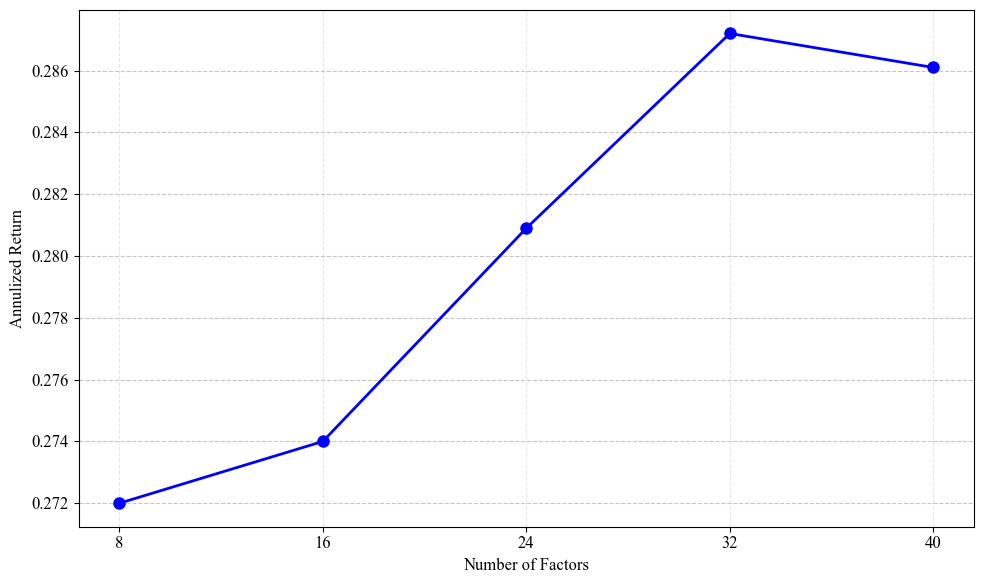

In [25]:
# Number of factors 年化報酬率
df = pd.DataFrame([
    {'factors_count': 8, 'GAC_cagr': 0.272},
    {'factors_count': 16, 'GAC_cagr': 0.274},
    {'factors_count': 24, 'GAC_cagr': 0.2809},
    {'factors_count': 32, 'GAC_cagr': 0.2872},
    {'factors_count': 40, 'GAC_cagr': 0.2861}
])

# plotting 折線圖
plt.figure(figsize=(10, 6))
plt.plot(df['factors_count'], df['GAC_cagr'], 'bo-', linewidth=2, markersize=8)
# plt.title('Annulized Return vs Number of Factors', fontsize=14)
plt.xlabel('Number of Factors', fontsize=12)
plt.ylabel('Annulized Return', fontsize=12)    
plt.xticks(df['factors_count'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f'{os.getcwd()}/backtest_llm_factor/out_stock/Plot/Number_of_Factors_vs_CAGR.png')
# ...existing code...


# Danger Zone

In [12]:
# # Delete folders named in the directory tree
# import os
# import shutil

# # Set the root directory for the project
# root_dir = r"/Users/yanyifu/Documents/_Coding/LLM Predict Stock/run_factor/out_stock/Training_result_TV/UsableThresDT_F24_EXP2"

# # Walk the directory tree and delete folders named 
# for dirpath, dirnames, filenames in os.walk(root_dir, topdown=False):
#     for dirname in dirnames:
#         if dirname.lower() == "3711":
#             full_path = os.path.join(dirpath, dirname)
#             print(f"Deleting folder: {full_path}")
#             shutil.rmtree(full_path)

In [12]:
# # 合併 Usable 跟 F42 變成 F24
# import json
# import os

# new_expands = {}

# for stock in data:
#     exp2_exist = False
#     print(f"stock: {stock[0]}")
#     if not os.path.exists(f"out_stock/Expands/F42/{stock[0]}/expand.json"):
#         print(f"{stock[0]} Not exist")
#         continue
    
#     with open(f"out_stock/Expands/F42/{stock[0]}/expand.json", "r") as f:
#         expand = json.load(f)
#     new_expands["model"] = expand["model"]
#     new_expands["temperature"] = expand["temperature"]
#     new_expands["stock_id"] = expand["stock_id"]
#     new_expands["output_data"] = {}
    
#     if os.path.exists(f"out_stock/Expands/FactorUsable/{stock[0]}/expand.json"):
#         exp2_exist = True
#         with open(f"out_stock/Expands/FactorUsable/{stock[0]}/expand.json", "r") as f:
#             expand2 = json.load(f)
    
#     date = expand["output_data"].keys()
#     for d in date:
#         # print(d)
#         new_expands["output_data"][d] = {"skeleton": {}}  # Ensure the structure exists

#         if exp2_exist:
#             # print("usable exist")
#             factors2 = expand2["output_data"][d]["skeleton"].keys()
#             for factor in factors2:
#                 new_expands["output_data"][d]["skeleton"][factor] = expand2["output_data"][d]['skeleton'][factor]
#         else:
#             print("usable not exist")
        
#         factors = expand["output_data"][d]["skeleton"].keys()
#         for factor in factors:
#             new_factor = str(int(factor) + 8)
#             if int(new_factor) > 24:
#                 continue
#             new_expands["output_data"][d]["skeleton"][new_factor] = expand["output_data"][d]['skeleton'][factor]


#     # print(new_expands["output_data"]["20230403"]['skeleton'])
#     os.makedirs(f"out_stock/Expands/F24/{stock[0]}", exist_ok=True)
#     with open(f"out_stock/Expands/F24/{stock[0]}/expand.json", "w") as f:
#         json.dump(new_expands, f, indent=4)
#     # break
    
        
        

In [6]:
# # rename path1 to path2
# import os

# for stock in data:
#     path1 = f"/Users/yanyifu/Documents/_Coding/LLM Predict Stock/run_factor/out_stock/Expands/FactorUsable/{stock[0]}/expand.json"
#     path2 = f"/Users/yanyifu/Documents/_Coding/LLM Predict Stock/run_factor/out_stock/Expands/UsableExp/{stock[0]}_expand.json"


#     os.rename(path1, path2)